In [1]:
# Install Tesseract OCR Engine dan Bahasa Indonesia
!apt-get update -y
!apt-get install -y tesseract-ocr tesseract-ocr-ind

# Install library Python pendukung
!pip install pytesseract opencv-python matplotlib numpy jiwer

Hit:1 http://archive.ubuntu.com/ubuntu noble InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Hit:3 https://cli.github.com/packages stable InRelease
Get:4 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:5 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Get:7 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease [17.8 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.3 MB]
Get:10 http://security.ubuntu.com/ubuntu noble-security/multiverse amd64 Packages [61.4 kB]
Get:11 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [2,066 kB]
Get:12 http://archive.ubuntu.com/ubuntu noble-updates/multiverse amd64 Packages [67.4 kB]
Get:13 http://archive.ubuntu.com/ubuntu noble-updates/restricted amd64 Packag

In [15]:
import os, re, io, cv2, time
import numpy as np
import pandas as pd
import pytesseract
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
from IPython.display import display

print("Pustaka siap")
print(pytesseract.get_tesseract_version())

Pustaka siap
5.3.4


In [16]:
uploaded = files.upload()
uploaded = {
    n: b for n, b in uploaded.items()
    if n.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
}
print("Jumlah gambar:", len(uploaded))
for n in uploaded:
    print(n)

Saving 09_CombinedDegradation.jpg to 09_CombinedDegradation.jpg
Saving 07_ColorShift_WarmTint.jpg to 07_ColorShift_WarmTint.jpg
Saving 08_JPEGCompression_Artifacts.jpg to 08_JPEGCompression_Artifacts.jpg
Saving 06_Faded_Underexposed.jpg to 06_Faded_Underexposed.jpg
Saving 05_LowResolution_Upsampled.jpg to 05_LowResolution_Upsampled.jpg
Saving 04_HighNoise.jpg to 04_HighNoise.jpg
Saving 03_Blurred.jpg to 03_Blurred.jpg
Saving 02_LowContrast.jpg to 02_LowContrast.jpg
Saving 01_HighQuality_Enhanced.jpg to 01_HighQuality_Enhanced.jpg
Jumlah gambar: 9
09_CombinedDegradation.jpg
07_ColorShift_WarmTint.jpg
08_JPEGCompression_Artifacts.jpg
06_Faded_Underexposed.jpg
05_LowResolution_Upsampled.jpg
04_HighNoise.jpg
03_Blurred.jpg
02_LowContrast.jpg
01_HighQuality_Enhanced.jpg


In [17]:
def load_image(data):
    img = Image.open(io.BytesIO(data)).convert("RGB")
    return cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

def preprocess_images(image):
    h, w = image.shape[:2]
    scale = min(1.0, 1600 / max(h, w))
    if scale < 1:
        image = cv2.resize(
            image, (int(w*scale), int(h*scale)),
            interpolation=cv2.INTER_AREA
        )

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(
        clipLimit=2.0, tileGridSize=(8,8)
    ).apply(gray)
    denoised = cv2.fastNlMeansDenoising(clahe, None, 10, 7, 21)
    adaptive = cv2.adaptiveThreshold(
        denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 31, 11
    )
    return {
        "CLAHE": clahe,
        "Denoising": denoised,
        "AdaptiveThreshold": adaptive
    }

In [18]:
def run_ocr(image):
    texts = []
    for psm in [6, 11, 12]:
        try:
            texts.append(pytesseract.image_to_string(
                image, lang="eng",
                config=f"--oem 3 --psm {psm}",
                timeout=12
            ))
        except Exception as e:
            print("OCR warning:", str(e)[:100])
    return max(texts, key=len).strip() if texts else ""


def extract_diploma_number(text):
    lines = [x.strip() for x in text.splitlines() if x.strip()]
    for i, line in enumerate(lines):
        if any(k in line.lower() for k in [
            "nomor ijazah", "no ijazah",
            "nomor seri", "diploma number"
        ]):
            candidate = re.sub(
                r"(?i).*?(nomor\s*ijazah|no\.?\s*ijazah|nomor\s*seri|diploma\s*number)\s*[:.]?\s*",
                "", line
            ).strip(" :-.")

            if re.search(r"\d", candidate) and len(candidate) >= 3:
                return candidate
            if i + 1 < len(lines) and re.search(r"\d", lines[i+1]):
                return lines[i+1]

    candidates = [x for x in lines if re.search(r"\d", x) and len(x) >= 4]
    return max(candidates, key=len) if candidates else "TIDAK TERBACA"


def detect_signature(gray):
    h, w = gray.shape
    roi = gray[int(h*.60):int(h*.95), int(w*.40):int(w*.98)]
    if roi.size == 0:
        return "TIDAK DAPAT DIPERIKSA"

    _, binary = cv2.threshold(
        cv2.GaussianBlur(roi, (3,3), 0), 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )
    ratio = np.count_nonzero(binary) / binary.size
    return "KEMUNGKINAN ADA" if .005 <= ratio <= .25 else "TIDAK TERDETEKSI"

In [19]:
results = []
preview_images = {}

for idx, (filename, data) in enumerate(uploaded.items(), start=1):
    print(f"Memproses {idx}/{len(uploaded)}: {filename}")
    try:
        image = load_image(data)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        signature = detect_signature(gray)

        for method, processed in preprocess_images(image).items():
            text = run_ocr(processed)
            results.append({
                "File": filename,
                "Metode": method,
                "Nomor Ijazah OCR": extract_diploma_number(text),
                "Teks OCR Lengkap": text,
                "Deteksi Tanda Tangan": signature
            })
            preview_images[(filename, method)] = processed
    except Exception as e:
        print("Gagal:", filename, str(e))

df = pd.DataFrame(results)
display(df[[
    "File", "Metode", "Nomor Ijazah OCR",
    "Deteksi Tanda Tangan"
]])
print("Jumlah percobaan:", len(df))

Memproses 1/9: 09_CombinedDegradation.jpg
Memproses 2/9: 07_ColorShift_WarmTint.jpg
Memproses 3/9: 08_JPEGCompression_Artifacts.jpg
Memproses 4/9: 06_Faded_Underexposed.jpg
Memproses 5/9: 05_LowResolution_Upsampled.jpg
Memproses 6/9: 04_HighNoise.jpg
Memproses 7/9: 03_Blurred.jpg
Memproses 8/9: 02_LowContrast.jpg
Memproses 9/9: 01_HighQuality_Enhanced.jpg


,File,Metode,Nomor Ijazah OCR,Deteksi Tanda Tangan
0,09_CombinedDegradation.jpg,CLAHE,g Ss oO nS 80 ae PREMERA SZ,KEMUNGKINAN ADA
1,09_CombinedDegradation.jpg,Denoising,571012022000056,KEMUNGKINAN ADA
2,09_CombinedDegradation.jpg,AdaptiveThreshold,571012022000056,KEMUNGKINAN ADA
3,07_ColorShift_WarmTint.jpg,CLAHE,571012022000056,KEMUNGKINAN ADA
4,07_ColorShift_WarmTint.jpg,Denoising,571012022000056,KEMUNGKINAN ADA
5,07_ColorShift_WarmTint.jpg,AdaptiveThreshold,571012022000056,KEMUNGKINAN ADA
6,08_JPEGCompression_Artifacts.jpg,CLAHE,571012022000056,KEMUNGKINAN ADA
7,08_JPEGCompression_Artifacts.jpg,Denoising,571012022000056,KEMUNGKINAN ADA
8,08_JPEGCompression_Artifacts.jpg,AdaptiveThreshold,571012022000056,KEMUNGKINAN ADA
9,06_Faded_Underexposed.jpg,CLAHE,J) 7 oO 00 gs = so ge 2,KEMUNGKINAN ADA


Jumlah percobaan: 27


Nama gambar: 09_CombinedDegradation.jpg


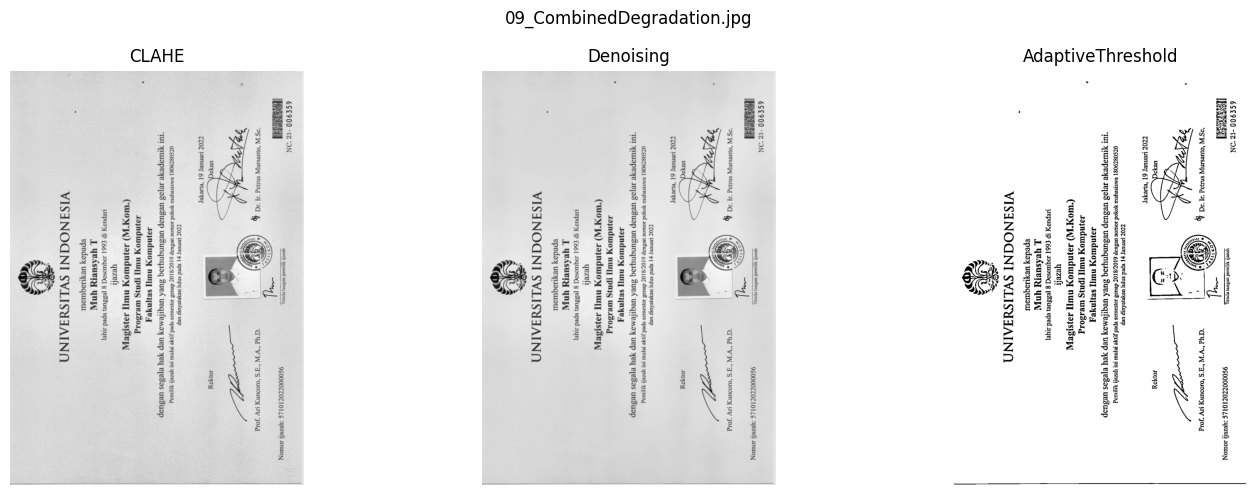

Nama gambar: 07_ColorShift_WarmTint.jpg


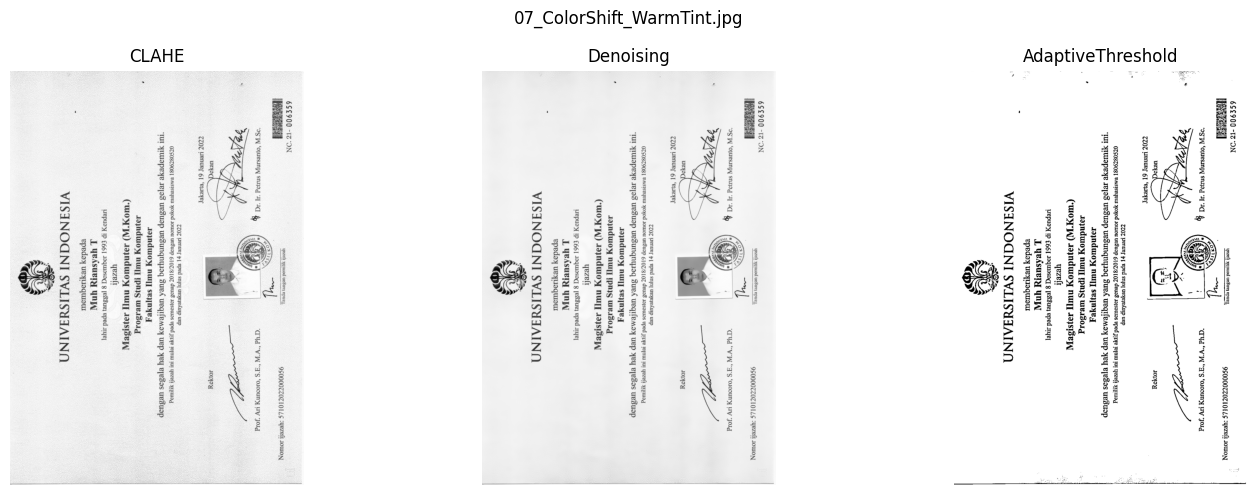

Nama gambar: 08_JPEGCompression_Artifacts.jpg


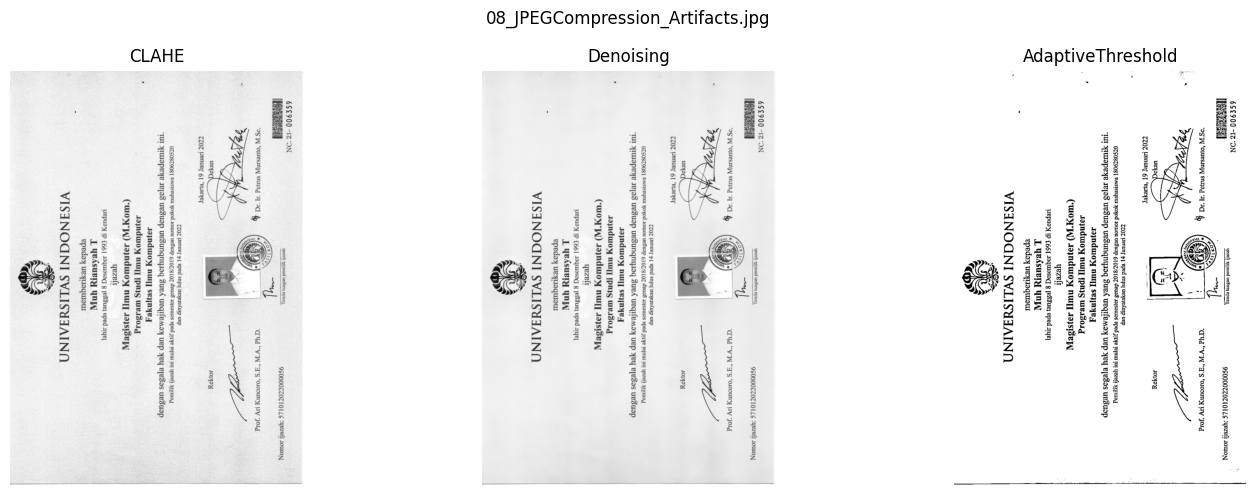

Nama gambar: 06_Faded_Underexposed.jpg


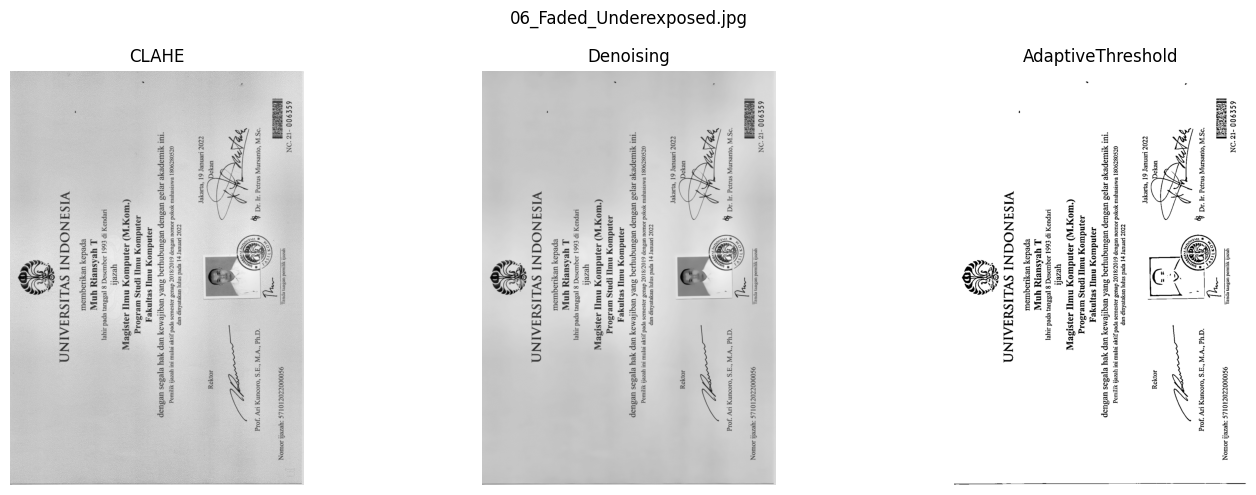

Nama gambar: 05_LowResolution_Upsampled.jpg


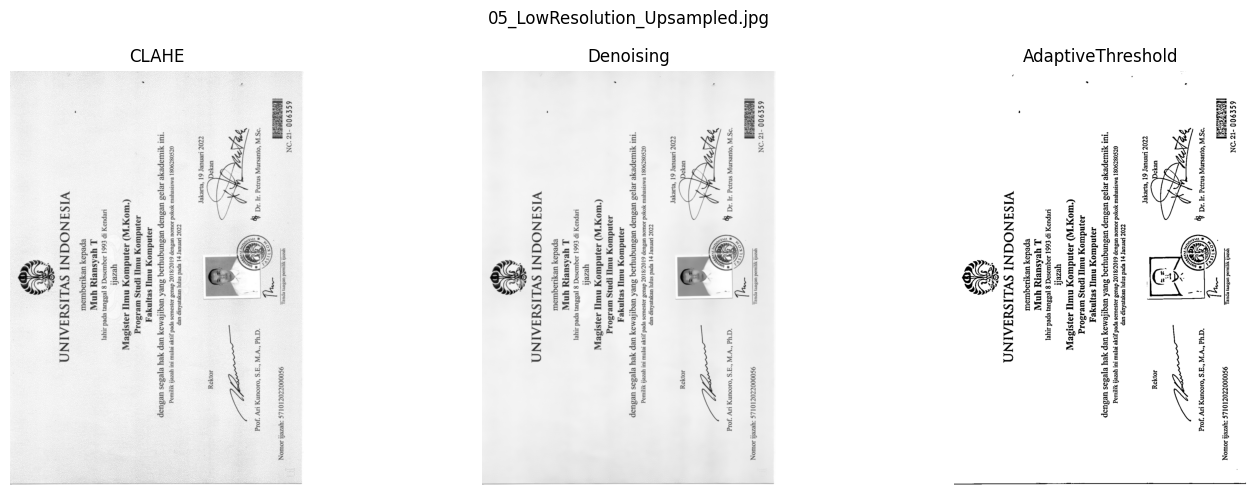

Nama gambar: 04_HighNoise.jpg


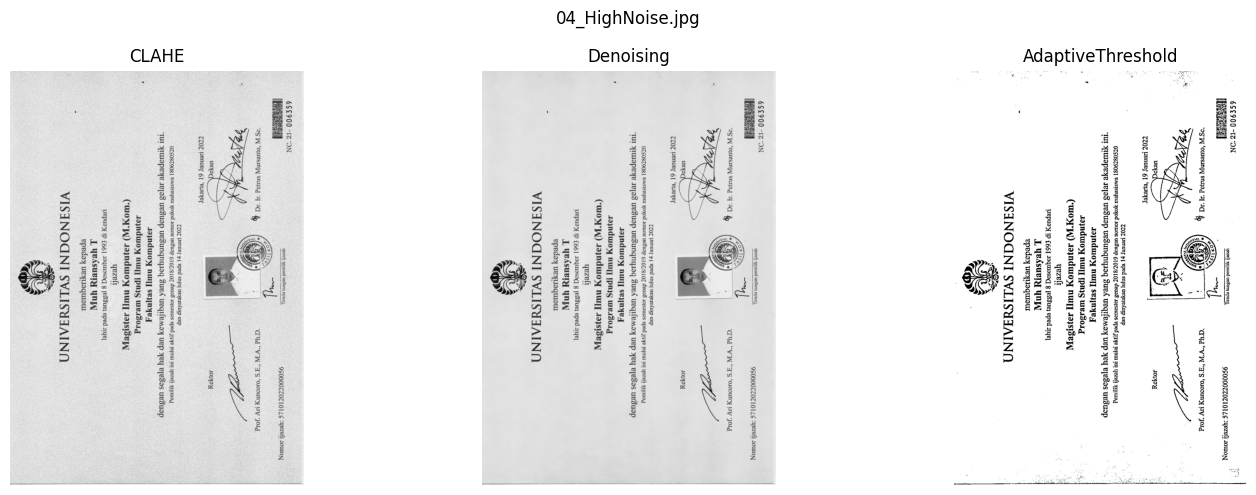

Nama gambar: 03_Blurred.jpg


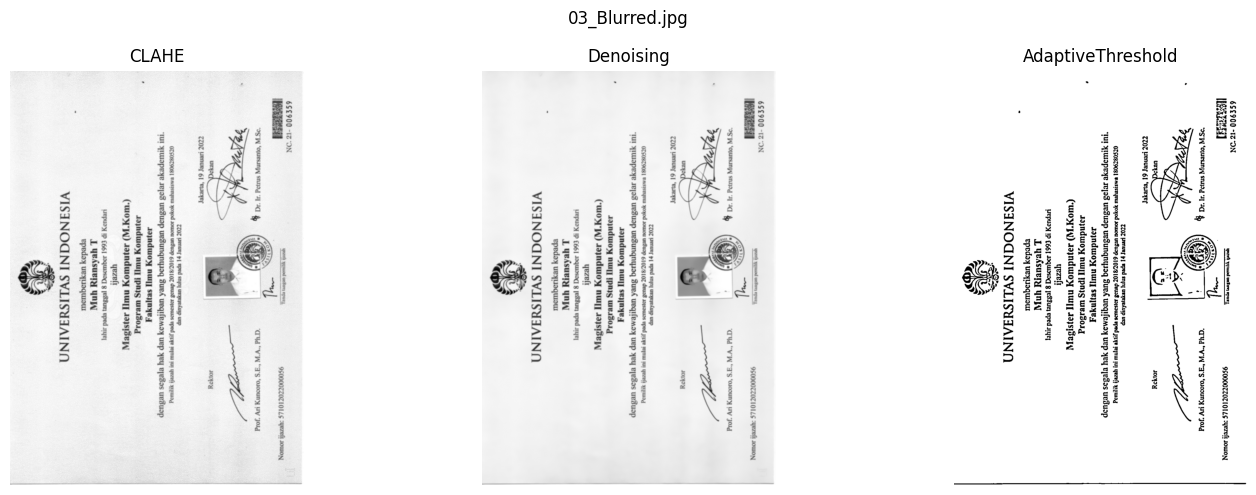

Nama gambar: 02_LowContrast.jpg


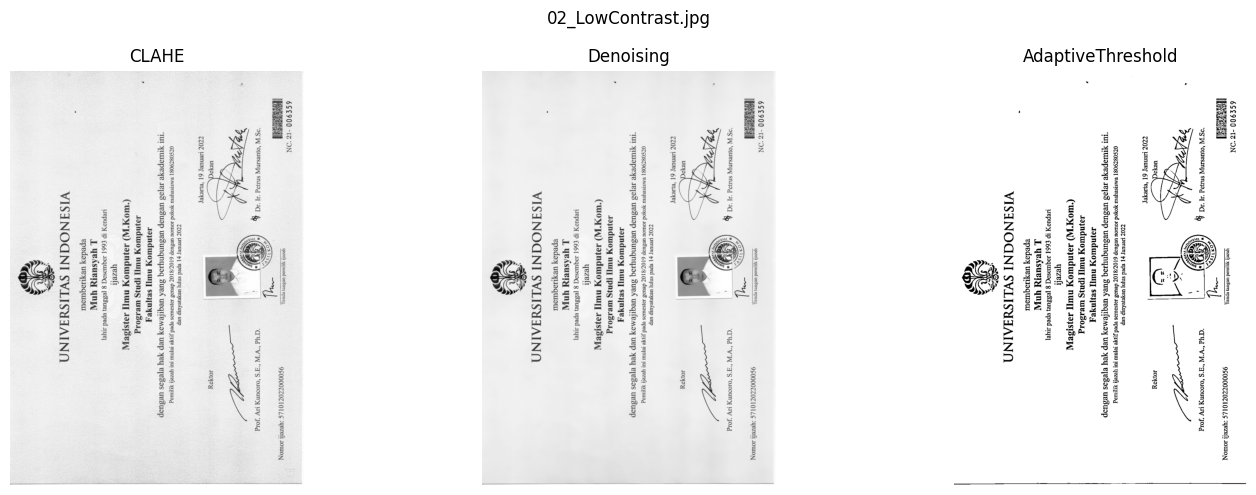

Nama gambar: 01_HighQuality_Enhanced.jpg


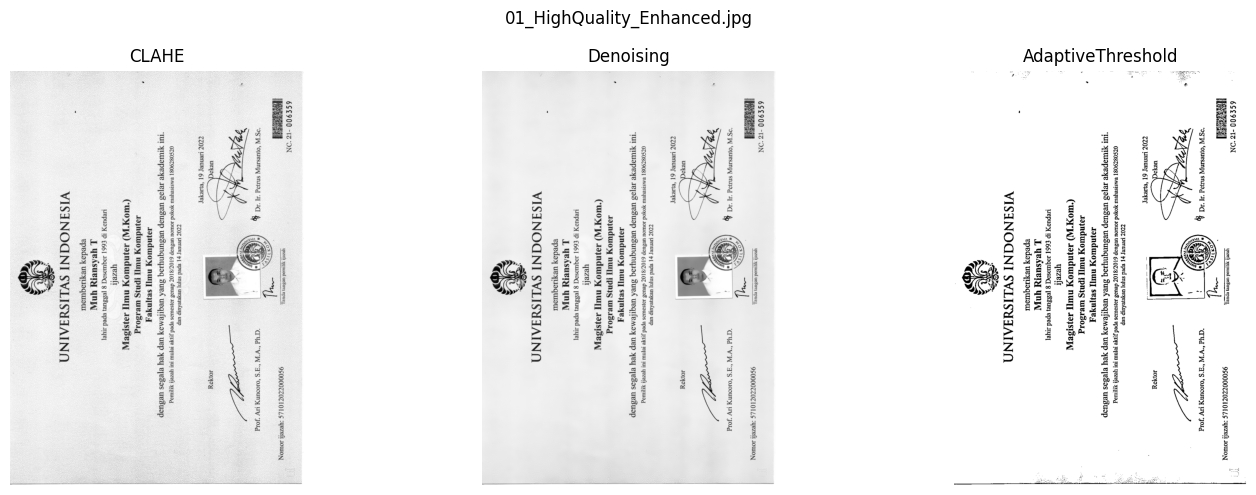

In [20]:
# Menampilkan semua gambar dengan 3 metode preprocessing

for nama_gambar in uploaded.keys():
    print("Nama gambar:", nama_gambar)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, method in zip(
        axes, ["CLAHE", "Denoising", "AdaptiveThreshold"]
    ):
        img = preview_images.get((nama_gambar, method))

        if img is not None:
            ax.imshow(img, cmap="gray")
            ax.set_title(method)
        else:
            ax.set_title(method + " - tidak tersedia")

        ax.axis("off")

    plt.suptitle(nama_gambar)
    plt.tight_layout()
    plt.show()

In [21]:
nomor_benar = "571010122022000056"

ground_truth = {
    nama_gambar: nomor_benar
    for nama_gambar in uploaded.keys()
}

print("Ground truth setiap gambar:")
for nama, nomor in ground_truth.items():
    print(nama, ":", nomor)

Ground truth setiap gambar:
09_CombinedDegradation.jpg : 571010122022000056
07_ColorShift_WarmTint.jpg : 571010122022000056
08_JPEGCompression_Artifacts.jpg : 571010122022000056
06_Faded_Underexposed.jpg : 571010122022000056
05_LowResolution_Upsampled.jpg : 571010122022000056
04_HighNoise.jpg : 571010122022000056
03_Blurred.jpg : 571010122022000056
02_LowContrast.jpg : 571010122022000056
01_HighQuality_Enhanced.jpg : 571010122022000056


In [22]:
# SEL 9 — HITUNG CER DAN BANDINGKAN METODE

import pandas as pd

def edit_distance(teks_asli, teks_ocr):
    m = len(teks_asli)
    n = len(teks_ocr)

    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i

    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            biaya = 0 if teks_asli[i - 1] == teks_ocr[j - 1] else 1

            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + biaya
            )

    return dp[m][n]


def hitung_cer(teks_asli, teks_ocr):
    teks_asli = str(teks_asli).strip()
    teks_ocr = str(teks_ocr).strip()

    if len(teks_asli) == 0:
        return 0.0 if len(teks_ocr) == 0 else 1.0

    return edit_distance(teks_asli, teks_ocr) / len(teks_asli)


# Nomor referensi yang sudah diverifikasi
nomor_benar = "571010122022000056"

data_cer = []

for hasil in results:
    nama = hasil["File"]
    metode = hasil["Metode"]
    teks_ocr = hasil["Nomor Ijazah OCR"]

    cer = hitung_cer(nomor_benar, teks_ocr)

    data_cer.append({
        "Nama Gambar": nama,
        "Metode": metode,
        "Ground Truth": nomor_benar,
        "Hasil OCR": teks_ocr,
        "CER (%)": round(cer * 100, 2)
    })


# Tabel hasil setiap gambar
df_cer = pd.DataFrame(data_cer)

print("HASIL CER SETIAP GAMBAR")
display(df_cer)


# Rata-rata CER per metode
ringkasan = (
    df_cer
    .groupby("Metode", as_index=False)
    .agg(
        Rata_rata_CER=("CER (%)", "mean"),
        Jumlah_Gambar=("Nama Gambar", "nunique")
    )
)

ringkasan["Rata_rata_CER"] = (
    ringkasan["Rata_rata_CER"].round(2)
)

ringkasan = ringkasan.sort_values(
    "Rata_rata_CER",
    ascending=True
)

print("PERBANDINGAN METODE PREPROCESSING")
display(ringkasan)

if not ringkasan.empty:
    terbaik = ringkasan.iloc[0]

    print("Metode dengan rata-rata CER terendah:",
          terbaik["Metode"])
    print("Rata-rata CER:",
          terbaik["Rata_rata_CER"], "%")

HASIL CER SETIAP GAMBAR


,Nama Gambar,Metode,Ground Truth,Hasil OCR,CER (%)
0,09_CombinedDegradation.jpg,CLAHE,571010122022000056,g Ss oO nS 80 ae PREMERA SZ,144.44
1,09_CombinedDegradation.jpg,Denoising,571010122022000056,571012022000056,16.67
2,09_CombinedDegradation.jpg,AdaptiveThreshold,571010122022000056,571012022000056,16.67
3,07_ColorShift_WarmTint.jpg,CLAHE,571010122022000056,571012022000056,16.67
4,07_ColorShift_WarmTint.jpg,Denoising,571010122022000056,571012022000056,16.67
5,07_ColorShift_WarmTint.jpg,AdaptiveThreshold,571010122022000056,571012022000056,16.67
6,08_JPEGCompression_Artifacts.jpg,CLAHE,571010122022000056,571012022000056,16.67
7,08_JPEGCompression_Artifacts.jpg,Denoising,571010122022000056,571012022000056,16.67
8,08_JPEGCompression_Artifacts.jpg,AdaptiveThreshold,571010122022000056,571012022000056,16.67
9,06_Faded_Underexposed.jpg,CLAHE,571010122022000056,J) 7 oO 00 gs = so ge 2,116.67


PERBANDINGAN METODE PREPROCESSING


,Metode,Rata_rata_CER,Jumlah_Gambar
2,Denoising,16.67,9
1,CLAHE,73.46,9
0,AdaptiveThreshold,85.19,9


Metode dengan rata-rata CER terendah: Denoising
Rata-rata CER: 16.67 %


In [23]:
# SEL 10 — SIMPAN HASIL KE CSV

# Simpan hasil CER setiap gambar
df_cer.to_csv(
    "hasil_ocr_dan_cer.csv",
    index=False,
    encoding="utf-8-sig"
)

# Simpan ringkasan perbandingan metode
ringkasan.to_csv(
    "ringkasan_perbandingan_metode.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Berhasil menyimpan 2 file:")
print("1. hasil_ocr_dan_cer.csv")
print("2. ringkasan_perbandingan_metode.csv")

# Unduh file hasil lengkap
from google.colab import files

files.download("hasil_ocr_dan_cer.csv")

Berhasil menyimpan 2 file:
1. hasil_ocr_dan_cer.csv
2. ringkasan_perbandingan_metode.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# SEL 12 — SIAPKAN SEMUA GAMBAR

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytesseract

daftar_gambar = {}

for nama in uploaded.keys():
    gambar = cv2.imread(nama)

    if gambar is None:
        print("Gambar gagal dibaca:", nama)
        continue

    gray = cv2.cvtColor(gambar, cv2.COLOR_BGR2GRAY)

    daftar_gambar[nama] = {
        "asli": gambar,
        "gray": gray
    }

print("Jumlah gambar berhasil dibaca:", len(daftar_gambar))

for nama, data in daftar_gambar.items():
    print(nama, data["gray"].shape)

Jumlah gambar berhasil dibaca: 9
09_CombinedDegradation.jpg (3506, 2481)
07_ColorShift_WarmTint.jpg (3506, 2481)
08_JPEGCompression_Artifacts.jpg (3506, 2481)
06_Faded_Underexposed.jpg (3506, 2481)
05_LowResolution_Upsampled.jpg (3506, 2481)
04_HighNoise.jpg (3506, 2481)
03_Blurred.jpg (3506, 2481)
02_LowContrast.jpg (3506, 2481)
01_HighQuality_Enhanced.jpg (3506, 2481)


In [25]:
# SEL 13 — ROI UNTUK SEMUA GAMBAR

# Format: (x_mulai, y_mulai, x_akhir, y_akhir)
# Nilai dalam proporsi 0 sampai 1.

roi_nomor_proporsi = (0.10, 0.70, 0.60, 0.90)
roi_ttd_proporsi = (0.45, 0.45, 0.95, 0.85)


def potong_roi(gambar, proporsi):
    h, w = gambar.shape[:2]
    x1, y1, x2, y2 = proporsi

    x1 = max(0, min(w, int(x1 * w)))
    x2 = max(0, min(w, int(x2 * w)))
    y1 = max(0, min(h, int(y1 * h)))
    y2 = max(0, min(h, int(y2 * h)))

    if x2 <= x1 or y2 <= y1:
        raise ValueError("Koordinat ROI tidak valid.")

    return gambar[y1:y2, x1:x2]


for nama, data in daftar_gambar.items():
    gray = data["gray"]

    data["roi_nomor"] = potong_roi(
        gray, roi_nomor_proporsi
    )
    data["roi_ttd"] = potong_roi(
        gray, roi_ttd_proporsi
    )

print("ROI selesai dibuat untuk semua gambar.")

ROI selesai dibuat untuk semua gambar.


Jumlah gambar yang akan ditampilkan: 9


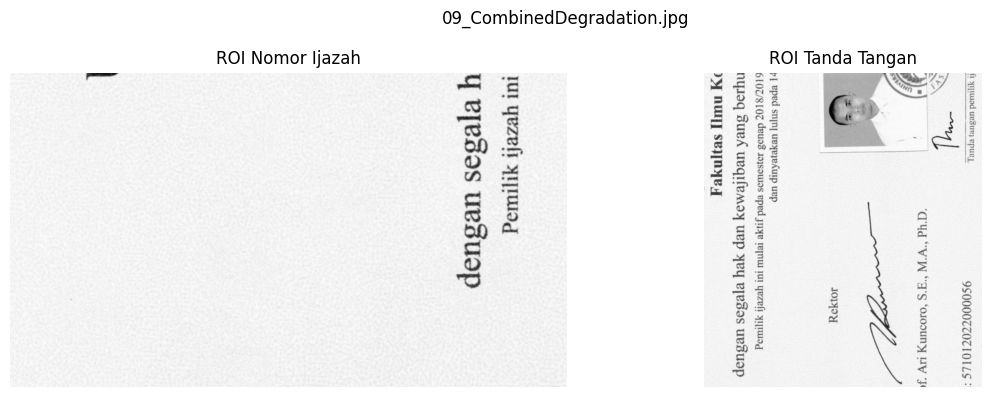

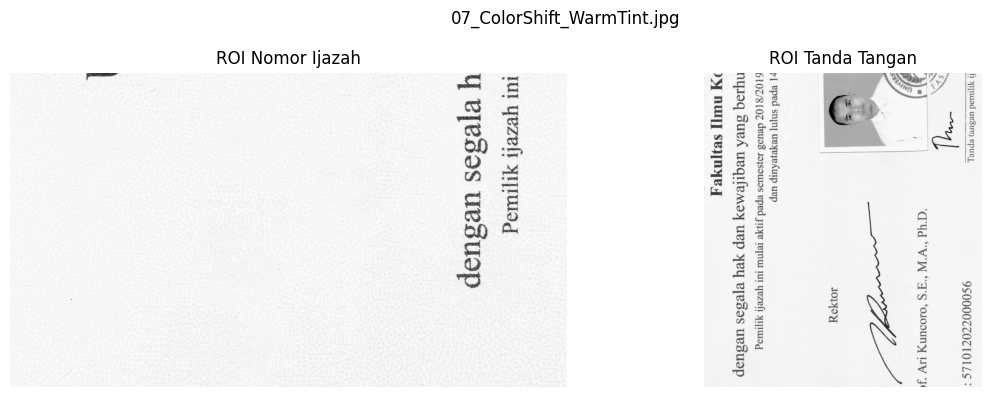

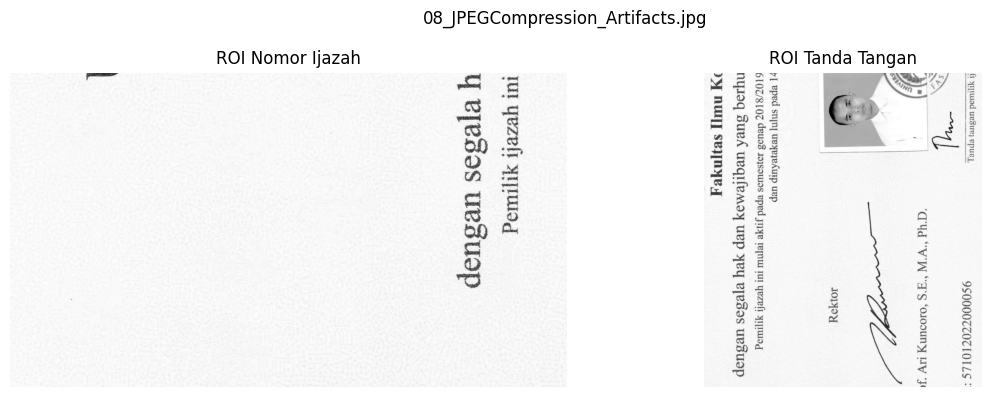

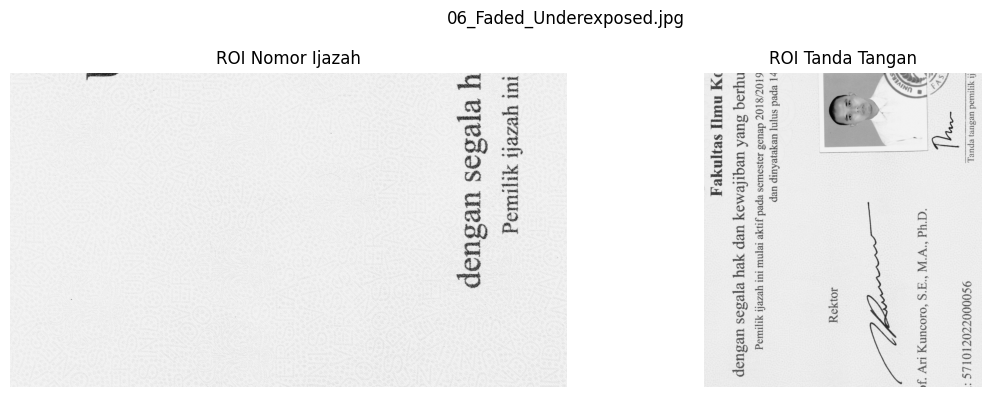

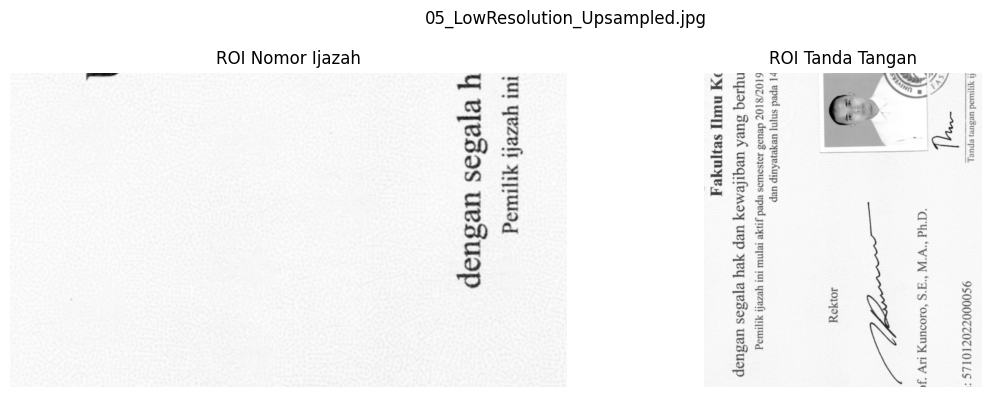

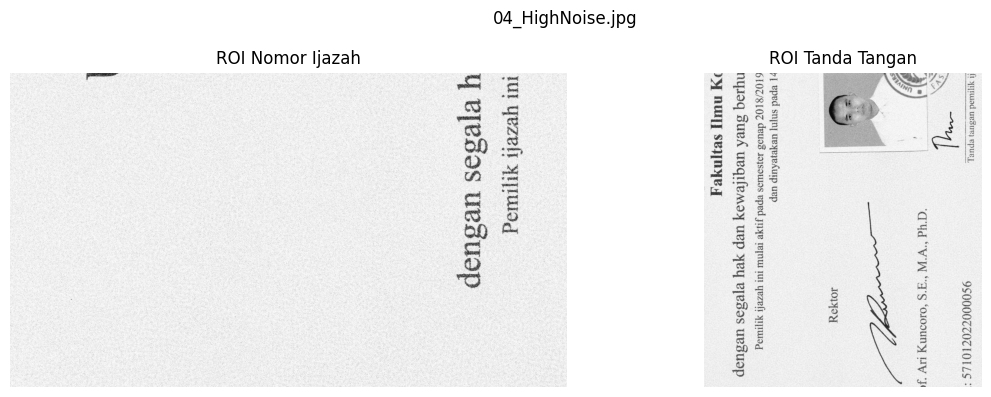

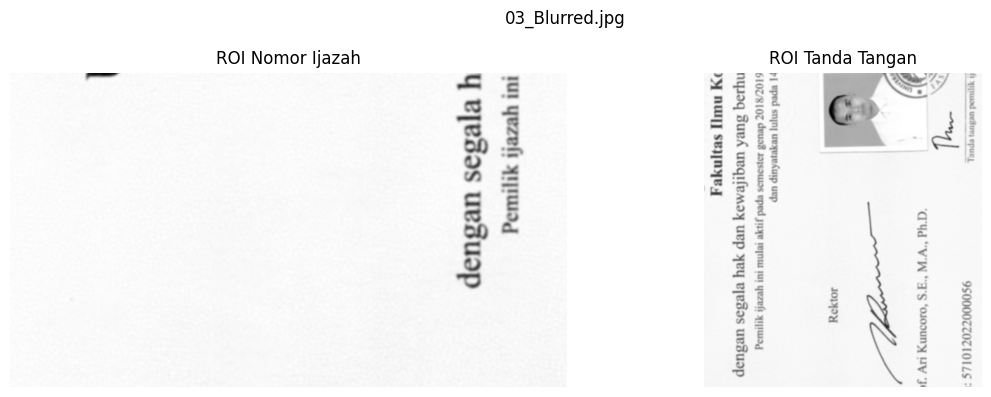

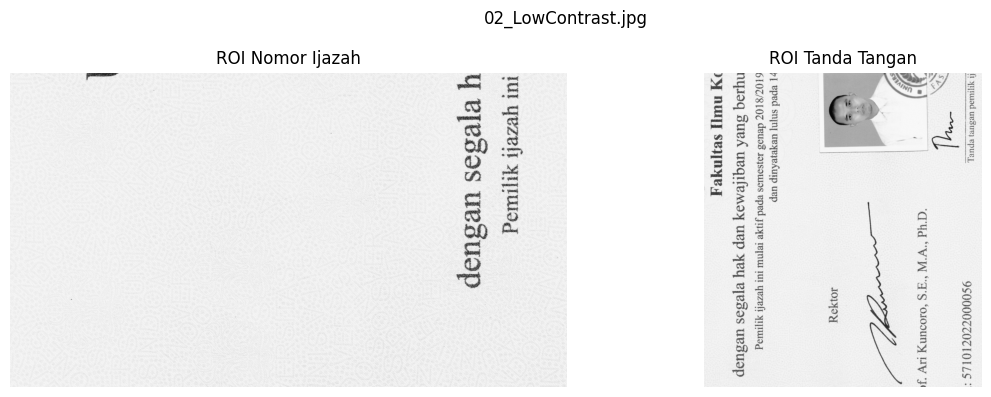

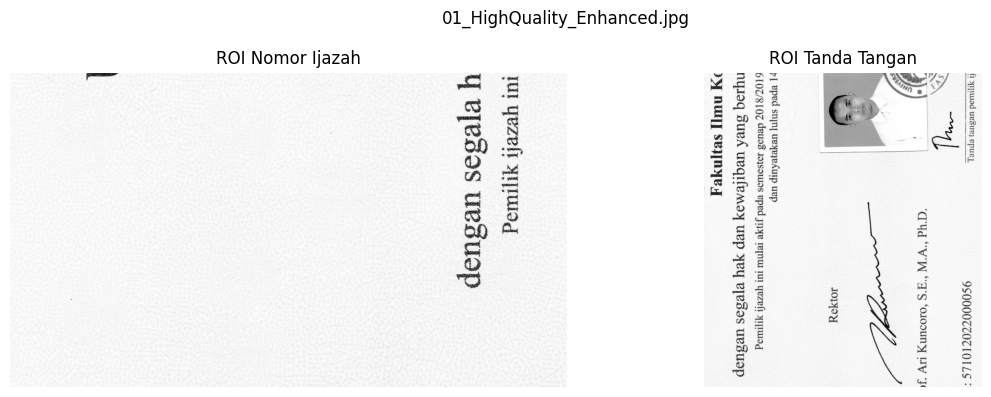

In [26]:
import matplotlib.pyplot as plt

print("Jumlah gambar yang akan ditampilkan:", len(daftar_gambar))

for nama, data in daftar_gambar.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(data["roi_nomor"], cmap="gray")
    axes[0].set_title("ROI Nomor Ijazah")
    axes[0].axis("off")

    axes[1].imshow(data["roi_ttd"], cmap="gray")
    axes[1].set_title("ROI Tanda Tangan")
    axes[1].axis("off")

    plt.suptitle(nama)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [27]:
import pytesseract
import pandas as pd
import cv2

hasil_ocr_semua = []

for nama, data in daftar_gambar.items():
    roi_nomor = data["roi_nomor"]

    # Perbesar ROI agar angka lebih mudah dibaca OCR
    roi_besar = cv2.resize(
        roi_nomor, None, fx=3, fy=3,
        interpolation=cv2.INTER_CUBIC
    )

    # Tingkatkan kontras dengan threshold
    roi_threshold = cv2.adaptiveThreshold(
        roi_besar, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31, 10
    )

    teks = pytesseract.image_to_string(
        roi_threshold,
        config="--psm 6 -c tessedit_char_whitelist=0123456789"
    )

    hasil_ocr_semua.append({
        "File": nama,
        "Nomor Ijazah OCR": teks.strip()
    })

df_ocr_semua = pd.DataFrame(hasil_ocr_semua)

display(df_ocr_semua)

,File,Nomor Ijazah OCR
0,09_CombinedDegradation.jpg,3
1,07_ColorShift_WarmTint.jpg,
2,08_JPEGCompression_Artifacts.jpg,8
3,06_Faded_Underexposed.jpg,4\n\n3\n\n3\n80606
4,05_LowResolution_Upsampled.jpg,8\n0
5,04_HighNoise.jpg,2\n2\n2\n8\n5\n7\n8\n2 1 8\n4\n4 38 2\n0\n1\n7...
6,03_Blurred.jpg,2\n2 4
7,02_LowContrast.jpg,8\n0\n7 2
8,01_HighQuality_Enhanced.jpg,7


In [28]:
!pip -q install jiwer
from jiwer import cer

# Ganti dengan nomor yang sudah kamu verifikasi
nomor_benar = "ISI_NOMOR_YANG_BENAR"

def hitung_cer(teks_ocr, referensi):
    prediksi = "".join(str(teks_ocr).split())
    referensi = "".join(str(referensi).split())

    if not referensi:
        return None

    return cer(referensi, prediksi)

df_ocr_semua["CER"] = df_ocr_semua[
    "Nomor Ijazah OCR"
].apply(lambda x: hitung_cer(x, nomor_benar))

display(df_ocr_semua)

,File,Nomor Ijazah OCR,CER
0,09_CombinedDegradation.jpg,3,1.00
1,07_ColorShift_WarmTint.jpg,,1.00
2,08_JPEGCompression_Artifacts.jpg,8,1.00
3,06_Faded_Underexposed.jpg,4\n\n3\n\n3\n80606,1.00
4,05_LowResolution_Upsampled.jpg,8\n0,1.00
5,04_HighNoise.jpg,2\n2\n2\n8\n5\n7\n8\n2 1 8\n4\n4 38 2\n0\n1\n7...,11.85
6,03_Blurred.jpg,2\n2 4,1.00
7,02_LowContrast.jpg,8\n0\n7 2,1.00
8,01_HighQuality_Enhanced.jpg,7,1.00


In [30]:
# Ekstrak deteksi tanda tangan unik untuk setiap file dari df atau results
df_ttd = df[["File", "Deteksi Tanda Tangan"]].drop_duplicates()

df_final = df_ocr_semua.merge(
    df_ttd,
    on="File",
    how="left"
)

df_final.to_csv(
    "hasil_evaluasi_9_gambar.csv",
    index=False
)

display(df_final)

from google.colab import files
files.download("hasil_evaluasi_9_gambar.csv")

,File,Nomor Ijazah OCR,CER,Deteksi Tanda Tangan
0,09_CombinedDegradation.jpg,3,1.00,KEMUNGKINAN ADA
1,07_ColorShift_WarmTint.jpg,,1.00,KEMUNGKINAN ADA
2,08_JPEGCompression_Artifacts.jpg,8,1.00,KEMUNGKINAN ADA
3,06_Faded_Underexposed.jpg,4\n\n3\n\n3\n80606,1.00,KEMUNGKINAN ADA
4,05_LowResolution_Upsampled.jpg,8\n0,1.00,KEMUNGKINAN ADA
5,04_HighNoise.jpg,2\n2\n2\n8\n5\n7\n8\n2 1 8\n4\n4 38 2\n0\n1\n7...,11.85,KEMUNGKINAN ADA
6,03_Blurred.jpg,2\n2 4,1.00,KEMUNGKINAN ADA
7,02_LowContrast.jpg,8\n0\n7 2,1.00,KEMUNGKINAN ADA
8,01_HighQuality_Enhanced.jpg,7,1.00,KEMUNGKINAN ADA


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

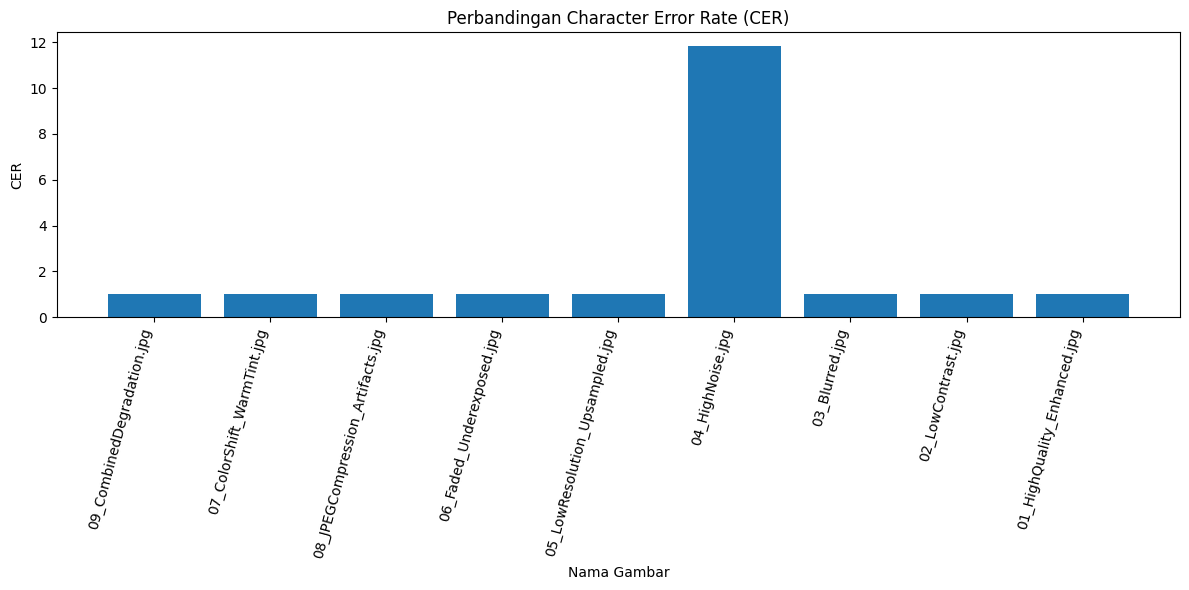

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    df_ocr_semua["File"],
    df_ocr_semua["CER"]
)

plt.title("Perbandingan Character Error Rate (CER)")
plt.xlabel("Nama Gambar")
plt.ylabel("CER")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

In [32]:
# Ringkasan performa OCR berdasarkan CER
df_valid = df_ocr_semua.dropna(subset=["CER"]).copy()

if len(df_valid) > 0:
    ringkasan_cer = (
        df_valid.groupby("File")["CER"]
        .mean()
        .sort_values()
    )

    print("=== PERINGKAT HASIL OCR ===")
    display(ringkasan_cer.reset_index(name="CER"))

    terbaik = ringkasan_cer.idxmin()
    terendah = ringkasan_cer.min()

    print("\nGambar dengan CER terendah:", terbaik)
    print("Nilai CER terendah:", round(terendah, 4))
else:
    print("Belum ada nilai CER yang valid. Periksa Sel 17.")

=== PERINGKAT HASIL OCR ===


,File,CER
0,01_HighQuality_Enhanced.jpg,1.00
1,02_LowContrast.jpg,1.00
2,03_Blurred.jpg,1.00
3,05_LowResolution_Upsampled.jpg,1.00
4,07_ColorShift_WarmTint.jpg,1.00
5,06_Faded_Underexposed.jpg,1.00
6,08_JPEGCompression_Artifacts.jpg,1.00
7,09_CombinedDegradation.jpg,1.00
8,04_HighNoise.jpg,11.85



Gambar dengan CER terendah: 01_HighQuality_Enhanced.jpg
Nilai CER terendah: 1.0


In [33]:
# SEL 21 - Kesimpulan hasil eksperimen OCR

df_valid = df_ocr_semua.dropna(subset=["CER"]).copy()

if df_valid.empty:
    print("Belum ada data CER. Periksa kembali Sel 17.")
else:
    rata_rata_cer = df_valid["CER"].mean()
    terbaik = df_valid.loc[df_valid["CER"].idxmin()]
    terburuk = df_valid.loc[df_valid["CER"].idxmax()]

    print("=== KESIMPULAN EKSPERIMEN OCR ===")
    print(f"Jumlah gambar dievaluasi: {len(df_valid)}")
    print(f"Rata-rata CER: {rata_rata_cer:.4f}")
    print(f"Gambar dengan CER terendah: {terbaik['File']}")
    print(f"CER terendah: {terbaik['CER']:.4f}")
    print(f"Gambar dengan CER tertinggi: {terburuk['File']}")
    print(f"CER tertinggi: {terburuk['CER']:.4f}")

    if rata_rata_cer == 0:
        print("Hasil OCR cocok dengan seluruh referensi pada data yang dievaluasi.")
    else:
        print("Masih terdapat kesalahan OCR dibandingkan nomor referensi.")
        print("Periksa hasil OCR dan pastikan nomor referensi benar.")

=== KESIMPULAN EKSPERIMEN OCR ===
Jumlah gambar dievaluasi: 9
Rata-rata CER: 2.2056
Gambar dengan CER terendah: 09_CombinedDegradation.jpg
CER terendah: 1.0000
Gambar dengan CER tertinggi: 04_HighNoise.jpg
CER tertinggi: 11.8500
Masih terdapat kesalahan OCR dibandingkan nomor referensi.
Periksa hasil OCR dan pastikan nomor referensi benar.


In [34]:
# SEL 22 - Simpan ringkasan evaluasi

df_valid = df_ocr_semua.dropna(subset=["CER"]).copy()

if not df_valid.empty:
    ringkasan_akhir = pd.DataFrame([{
        "Jumlah Gambar": len(df_valid),
        "Rata-rata CER": df_valid["CER"].mean(),
        "CER Terendah": df_valid["CER"].min(),
        "CER Tertinggi": df_valid["CER"].max()
    }])

    ringkasan_akhir.to_csv(
        "ringkasan_eksperimen.csv",
        index=False
    )

    display(ringkasan_akhir)

    from google.colab import files
    files.download("ringkasan_eksperimen.csv")
else:
    print("Data CER belum tersedia. Periksa Sel 17.")

,Jumlah Gambar,Rata-rata CER,CER Terendah,CER Tertinggi
0,9,2.205556,1.0,11.85


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>